# Day 4 — t-SNE & Anomaly Detection

## Objectives

- Use t-SNE to visualize high-dimensional data.
- Understand the difference between PCA and t-SNE.
- Explain anomaly detection and why it is often unsupervised.
- Detect anomalies using Isolation Forest.
- Interpret the points flagged as anomalies.

## 1. t-SNE for Visualization

t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality
reduction technique designed primarily for visualization.

Unlike PCA, which focuses on preserving global variance, t-SNE focuses
on preserving local neighborhoods.

This means that points that are close together in the original
high-dimensional space are encouraged to remain close together in the
2D representation.

t-SNE is useful for visually identifying possible clusters, but its axes
do not have a direct interpretable meaning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv(
    r"D:\Desktop\AI & ML BinX Tech\Python\Week 1\tested.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

X = df[features].copy()

X = X.fillna(X.median())

X.isnull().sum()

Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (418, 5)
Scaled shape: (418, 5)


In [5]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

X_tsne.shape

(418, 2)

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

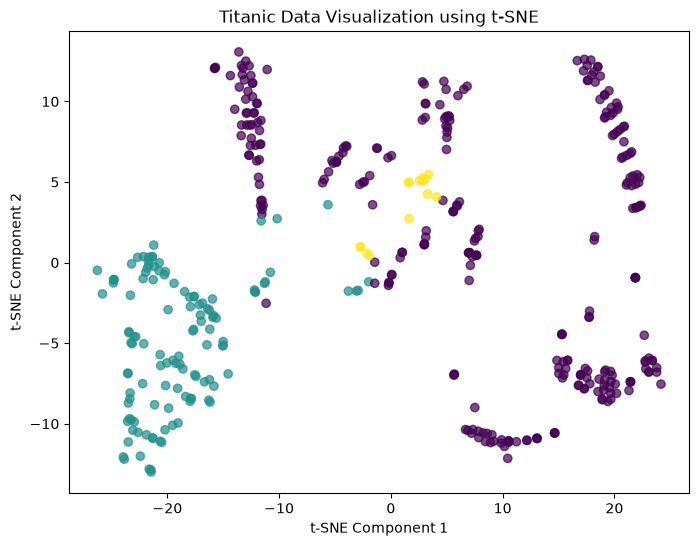

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels,
    alpha=0.7
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Titanic Data Visualization using t-SNE")

plt.show()

## 2. PCA vs t-SNE

PCA and t-SNE are both dimensionality reduction techniques, but they
serve different purposes.

| PCA | t-SNE |
|---|---|
| Preserves global variance | Preserves local neighborhoods |
| Useful for compression and visualization | Mainly used for visualization |
| Relatively fast | Slower on larger datasets |
| Components represent directions of variance | Axes have no direct meaning |
| More suitable for downstream modeling | Primarily used to explore structure visually |

PCA is useful when dimensionality reduction is needed for modeling or
when preserving global variance is important.

t-SNE is useful when the main goal is to visualize local structure and
potential clusters.

## 3. Anomaly Detection

Anomaly detection identifies observations that differ significantly from
the normal pattern in a dataset.

It is often unsupervised because anomalies are usually rare and may not
have predefined labels.

Examples include:

- Fraudulent transactions
- Manufacturing defects
- System failures
- Data errors

The model learns the general structure of normal observations and flags
points that behave differently.

In [9]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

preds = iso.fit_predict(X_scaled)

preds[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [11]:
n_anomalies = (preds == -1).sum()
n_normal = (preds == 1).sum()

print("Number of normal points:", n_normal)
print("Number of anomalies:", n_anomalies)
print("Total points:", len(preds))

Number of normal points: 397
Number of anomalies: 21
Total points: 418


In [12]:
results = X.copy()

results["Anomaly"] = preds

results.head()

,Pclass,Age,SibSp,Parch,Fare,Anomaly
0,3,34.5,0,0,7.8292,1
1,3,47.0,1,0,7.0000,1
2,2,62.0,0,0,9.6875,1
3,3,27.0,0,0,8.6625,1
4,3,22.0,1,1,12.2875,1


In [13]:
anomalies = results[results["Anomaly"] == -1]

anomalies.head(2)

,Pclass,Age,SibSp,Parch,Fare,Anomaly
24,1,48.0,1,3,262.375,-1
53,1,28.0,3,2,263.000,-1


In [14]:
# Get anomaly indices
anomaly_indices = X.index[preds == -1]

# Inspect the first two anomalies
X.loc[anomaly_indices[:2]]

,Pclass,Age,SibSp,Parch,Fare
24,1,48.0,1,3,262.375
53,1,28.0,3,2,263.000


## Anomaly Inspection

Isolation Forest flagged 21 observations as anomalies out of 418 total observations.

Two flagged observations were inspected:

- Observation 24: Pclass = 1, Age = 48, SibSp = 1, Parch = 3, Fare = 262.375
- Observation 53: Pclass = 1, Age = 28, SibSp = 3, Parch = 2, Fare = 263.000

Both observations have unusually high Fare values compared with most observations in the dataset. Their family-size features also differ from the common patterns in the data.

These unusual feature combinations may have made the observations easier for Isolation Forest to isolate, resulting in their classification as anomalies.

### PCA vs t-SNE

PCA preserves global variance and provides components that represent directions of
variation in the original feature space.

t-SNE focuses on preserving local neighborhoods and is mainly used for visualization.
Its axes do not have a direct interpretable meaning.

For this dataset, PCA provides a compact representation of the overall variance,
while t-SNE provides a clearer visual representation of local groupings and can reveal
structures that are less obvious in the PCA projection.

Therefore, PCA is more suitable for dimensionality reduction and retaining variance,
while t-SNE is mainly useful for exploring and visualizing high-dimensional data.